In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import datetime
import matplotlib.cm as cm 
import matplotlib.colors as mcolors

### Reading Dataset

In [15]:
df = pd.read_csv("../data_collection/data/dar_to_bhm.csv")
df.columns

Index(['rid', 'toc_code', 'date', 'month', 'day', 'cancelled', 'canc_reason',
       'init_station', 'init_ptd', 'init_atd', 'start_station', 'start_pta',
       'start_ata', 'start_arrival_delay', 'start_ptd', 'start_atd',
       'start_dept_delay', 'distance_from_init', 'end_station', 'end_pta',
       'end_ata', 'end_delay', 'delayed'],
      dtype='str')

In [16]:
# Step 1: I would like to seperate the trains that were cancelled from the rest.

cancelled_trains = df.loc[lambda df: df['cancelled'] == True, ['rid','toc_code','date','month','day','canc_reason','init_station', 'init_ptd']]

# Load into a new csv file

cancelled_trains.to_csv("cleaned_data/cancelled_trains_dar_to_bhm.csv", index=False)

print(f"{(cancelled_trains.shape[0]/df.shape[0])*100:.2f}% of trains from Darlington to Birmingham were cancelled in the period 2025-09-20 to 2026-09-13.")

4.37% of trains from Darlington to Birmingham were cancelled in the period 2025-09-20 to 2026-09-13.


In [17]:
print(f"{100- np.isnan(cancelled_trains['canc_reason']).mean() * 100:.2f}% of the trains cancelled last year were cancelled with reason.")

93.40% of the trains cancelled last year were cancelled with reason.


<Axes: xlabel='canc_reason'>

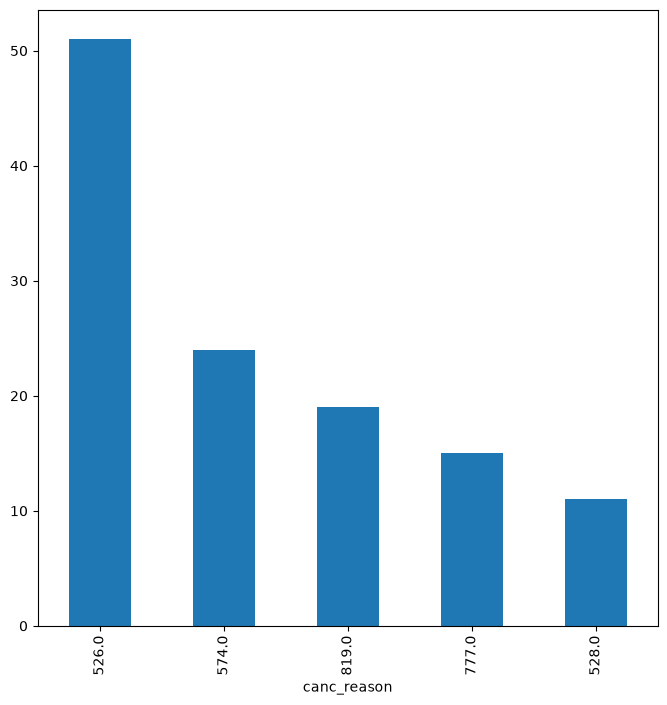

In [18]:
cancelled_trains_reasons = cancelled_trains.dropna(axis=0)
fig, ax = plt.subplots(figsize=(8,8))
cancelled_trains_reasons['canc_reason'].value_counts().head().plot(ax=ax, kind='bar')

In [19]:
not_cancelled_trains = df.loc[lambda df: df['cancelled'] == False]

# Load into a new csv file

not_cancelled_trains.to_csv("cleaned_data/not_cancelled_trains_dar_to_bhm.csv", index=False)

delayed_trains = not_cancelled_trains['delayed'].value_counts()

print(f"Out of the trains that weren't cancelled, {(delayed_trains[0]/not_cancelled_trains.shape[0])*100:.2f}% arrived on time.")

Out of the trains that weren't cancelled, 28.81% arrived on time.


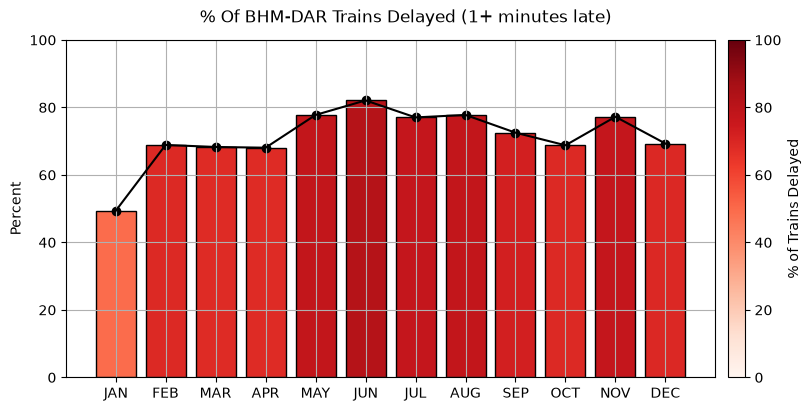

In [20]:
# Plotting the number of delayed trains by month.
# Extract train delays:

months = ["JAN", "FEB", "MAR", "APR", "MAY", "JUN", "JUL", "AUG", "SEP", "OCT", "NOV", "DEC"]

def get_delays():
    res = {} 
    delayed = not_cancelled_trains.loc[lambda df: df['delayed'] == True]
    for month in months:
        monthly_delays = delayed.loc[lambda df: df['month'] == month] 
        monthly_all_trains = not_cancelled_trains.loc[lambda df: df['month'] == month]
        res[month] = (monthly_delays.shape[0]/monthly_all_trains.shape[0])*100
    return res


data = get_delays()

names = list(data.keys())
values = list(data.values())

norm = mcolors.Normalize(vmin=0, vmax=100)
cmap = cm.Reds
colors = [cmap(norm(v)) for v in values]

fig, axs = plt.subplots(figsize=(8,4), sharey=True, layout = 'constrained')
axs.grid()
axs.bar(names, values, color=colors, edgecolor = 'blacK')
axs.plot(names, values, color='black')
axs.set_ylim(0,100)
axs.set_ylabel("Percent")
axs.scatter(names, values, color='black')

# Add colourbar for reference
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=axs, label='% of Trains Delayed', pad=0.02)
fig.suptitle("% Of BHM-DAR Trains Delayed (1+ minutes late)") # It's kind of clear that we're missing values.

plt.show()



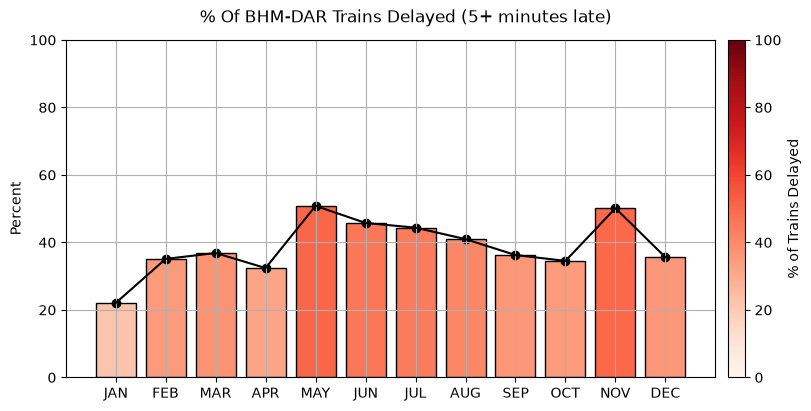

In [21]:
# Plotting the number of delayed trains by month, according to the train operators. 
# Late = 5 or more minutes late.
# Extract train delays:

months = ["JAN", "FEB", "MAR", "APR", "MAY", "JUN", "JUL", "AUG", "SEP", "OCT", "NOV", "DEC"]

def get_delays():
    res = {} 
    delayed = not_cancelled_trains.loc[lambda df: df['end_delay'] >= 5]
    for month in months:
        monthly_delays = delayed.loc[lambda df: df['month'] == month] 
        monthly_all_trains = not_cancelled_trains.loc[lambda df: df['month'] == month]
        res[month] = (monthly_delays.shape[0]/monthly_all_trains.shape[0])*100
    return res


data = get_delays()

names = list(data.keys())
values = list(data.values())

norm = mcolors.Normalize(vmin=0, vmax=100)
cmap = cm.Reds
colors = [cmap(norm(v)) for v in values]

fig, axs = plt.subplots(figsize=(8,4), sharey=True, layout = 'constrained')
axs.grid()
axs.bar(names, values, color=colors, edgecolor = 'blacK')
axs.plot(names, values, color='black')
axs.set_ylim(0,100)
axs.set_ylabel("Percent")
axs.scatter(names, values, color='black')

# Add colourbar for reference
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=axs, label='% of Trains Delayed', pad=0.02)
fig.suptitle("% Of BHM-DAR Trains Delayed (5+ minutes late)") # It's kind of clear that we're missing values.

plt.show()



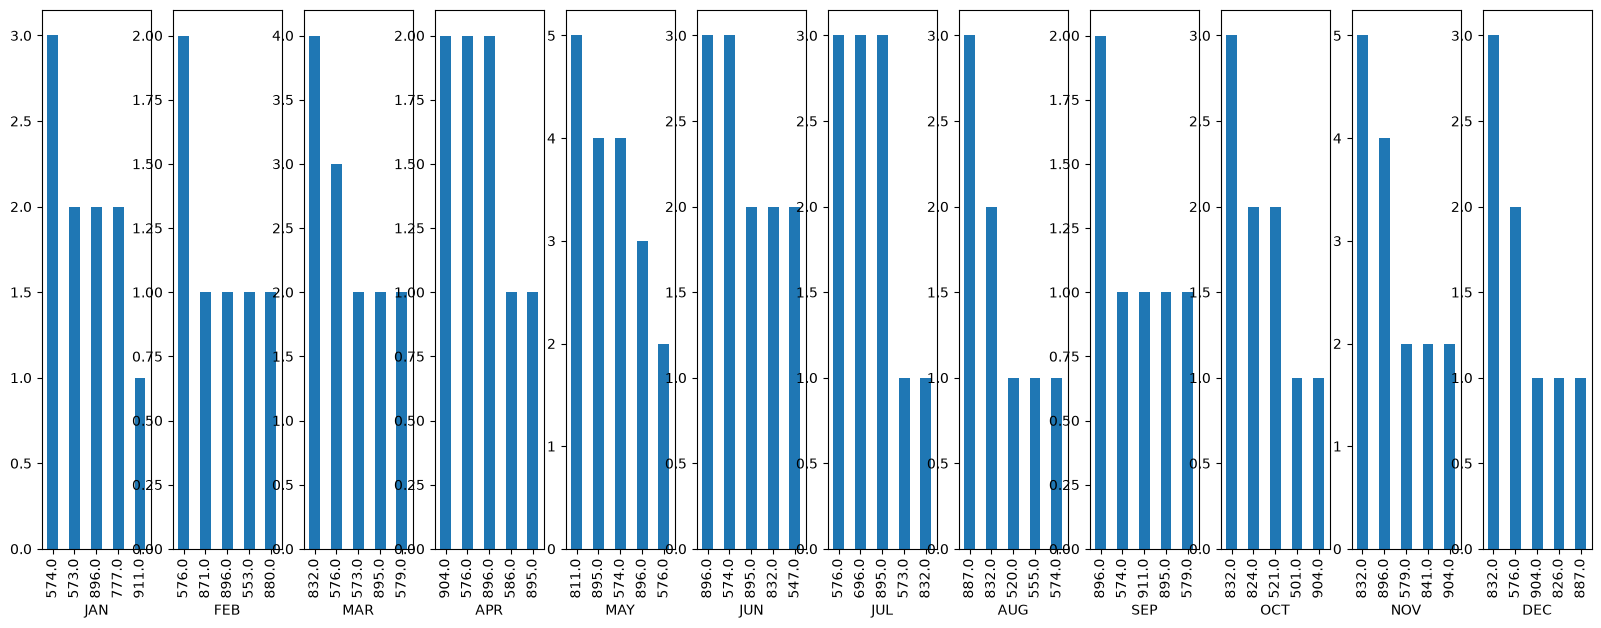

In [22]:
# Plotting Train Cancellation Reasons per Month

def get_late_canc_reasons(month):
    trains = not_cancelled_trains[lambda df: df['month'] == month]
    very_delayed = trains[lambda df : df['end_delay'] >= 30]
    reasons = very_delayed['canc_reason'].value_counts().head()
    return reasons

fig, ax = plt.subplots(1,12, figsize=(20,7))
for i in range(12):
    reasons = get_late_canc_reasons(months[i])
    reasons.plot(ax=ax[i], kind='bar')
    ax[i].set_xlabel(months[i])
    

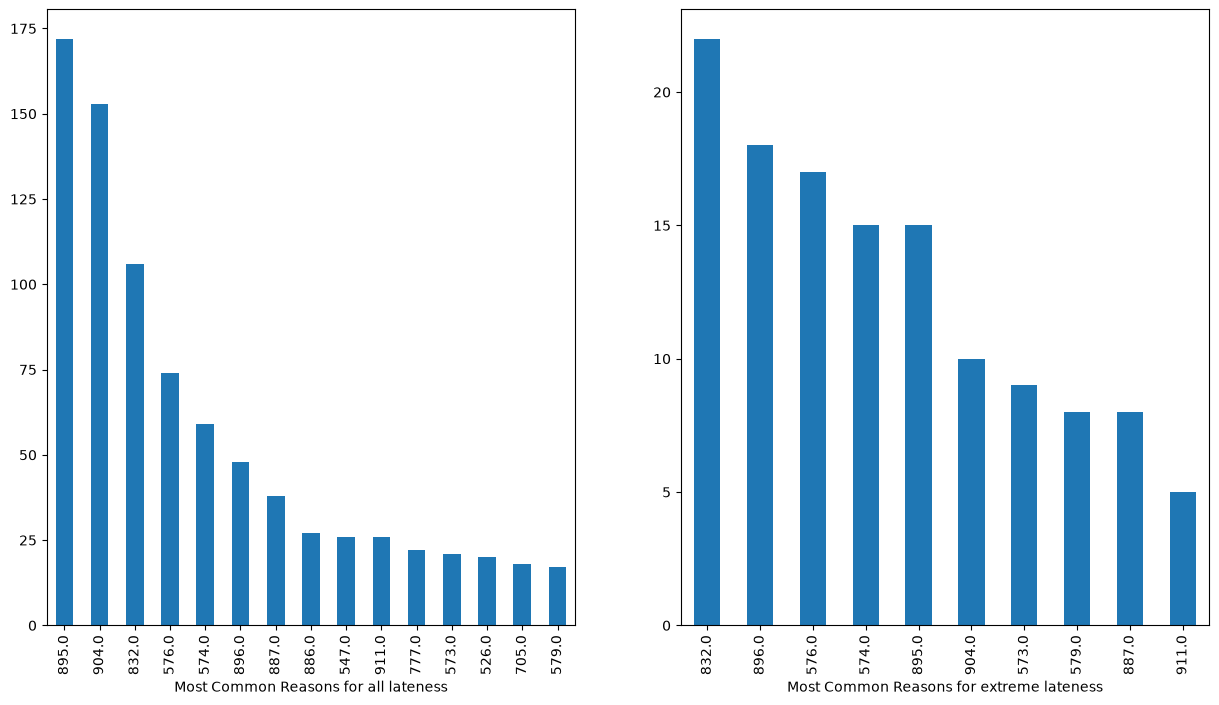

In [23]:
# Histogram of the most common reasons for lateness (NOT cancellation)

fig, axs = plt.subplots(1,2, figsize=(15,8))
not_cancelled_trains['canc_reason'].value_counts().head(15).plot(ax=axs[0], kind='bar') 
axs[0].set_xlabel('Most Common Reasons for all lateness')

very_late_trains = not_cancelled_trains.loc[lambda df: df['end_delay'] >= 30]
very_late_trains['canc_reason'].value_counts().head(10).plot(ax=axs[1], kind='bar')
axs[1].set_xlabel('Most Common Reasons for extreme lateness')
plt.show()

Text(0.5, 0.98, '% Of BHM-DAR Trains Delayed (5+ Minutes)')

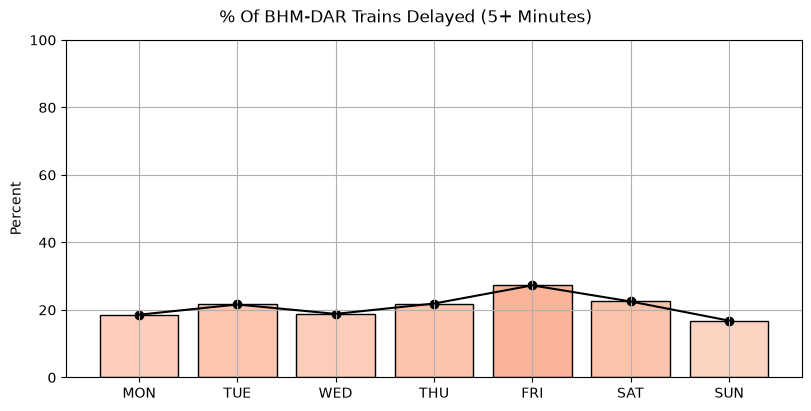

In [29]:
# Plot % of trains delayed by day.
days = ["MON", "TUE", "WED", "THU", "FRI", "SAT", "SUN"]

def get_delays():
    res = {} 
    delayed = not_cancelled_trains.loc[lambda df: df['end_delay'] >= 10]
    for day in days:
        daily_delays = delayed.loc[lambda df: df['day'] == day] 
        daily_all_trains = not_cancelled_trains.loc[lambda df: df['day'] == day]
        res[day] = (daily_delays.shape[0]/daily_all_trains.shape[0])*100
    return res


data = get_delays()

names = list(data.keys())
values = list(data.values())

norm = mcolors.Normalize(vmin=0, vmax=100)
cmap = cm.Reds
colors = [cmap(norm(v)) for v in values]

fig, axs = plt.subplots(figsize=(8,4), sharey=True, layout = 'constrained')
axs.grid()
axs.bar(names, values, color=colors, edgecolor = 'blacK')
axs.plot(names, values, color='black')
axs.set_ylim(0,100)
axs.set_ylabel("Percent")
axs.scatter(names, values, color='black')
fig.suptitle("% Of BHM-DAR Trains Delayed (5+ Minutes)") # It's kind of clear that we're missing values.

If we are understanding 'delayed' to mean 5+ minutes late, then we see that Friday trains are more likely to be delayed.

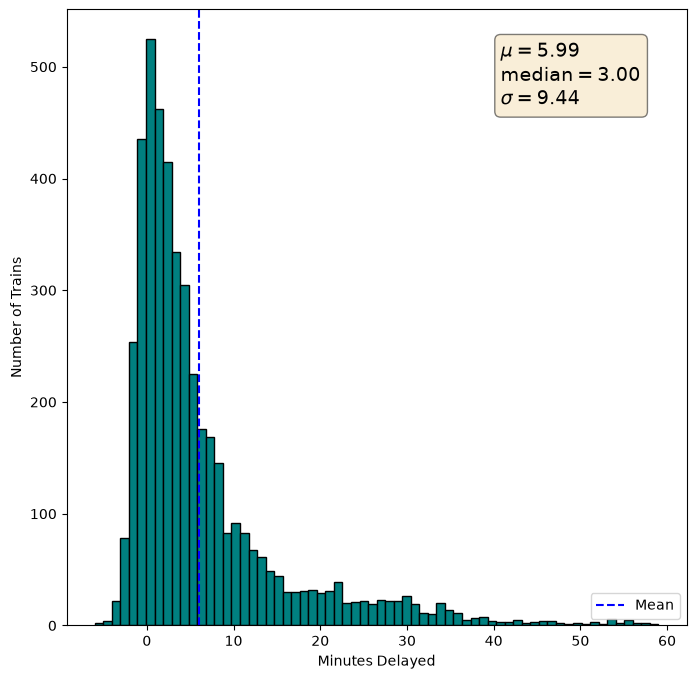

In [ ]:
# Plot all delays among not cancelled trains.

delays = list(not_cancelled_trains.loc[lambda df: (df['end_delay'] >= -10) & (df['end_delay'] <=60)]['end_delay'])

unique_num_delays = len(set(delays))

mu = np.mean(delays)
median = np.median(delays)
sigma = np.std(delays)

textstr = '\n'.join((
    r'$\mu=%.2f$' % (mu, ),
    r'$\mathrm{median}=%.2f$' % (median, ),
    r'$\sigma=%.2f$' % (sigma, )))

fig, ax = plt.subplots(figsize=(8,8))
ax.hist(delays, bins=unique_num_delays, edgecolor ='black', color='teal')
ax.set_xlabel('Minutes Delayed')
ax.set_ylabel('Number of Trains')

props = {
    "boxstyle":"round",
    "facecolor":"wheat",
    "alpha":0.5
}


ax.text(0.70, 0.95, textstr, transform=ax.transAxes, fontsize=14, verticalalignment='top', bbox=props)

ax.axvline(x=mu, linestyle='--',color='blue', label='Mean')
plt.legend()
plt.show()